# Script to estimate airborne fraction trends with all LULC measurement

combinations

Fossil emissions and atmospheric growth from GCB 2025 with LULC panel measurements

[J. Eduardo Vera-Valdés](https://everval.github.io) [](https://orcid.org/0000-0002-0337-8055) (Aalborg University, CoRE)

## Script to run the mixes model analysis

Load the dataset and the LULC measurement panel.

In [1]:
#| warning: false
#| message: false
#| output: false
cd(@__DIR__)
using Pkg
Pkg.activate(pwd())

using CSV
using DataFrames
using Statistics
include(joinpath(@__DIR__, "estimation_functions.jl"))

dataframe_to_markdown_table (generic function with 1 method)

In [1]:
data_path = joinpath(@__DIR__, "..", "data", "Data_GCB_2025_cols.csv")
lulc_path = joinpath(@__DIR__, "..", "results", "LULC_measurements_extracted_and_derived.csv")
vai_path = joinpath(@__DIR__, "..", "data", "Data_vai_enso.csv")

gcb_df = CSV.read(data_path, DataFrame)
lulc_df = CSV.read(lulc_path, DataFrame)
rename!(lulc_df, :year => :Year);
vai_df = CSV.read(vai_path, DataFrame)

# First-stage Growth specification (same as growth_measurements.qmd):
# Growth_t = a0 + a1*(Fossil_t + mean(LULC)_t) + a2*VAI_t + a3*ENSO_t
lulc_measure_cols = filter(col -> col != "Year", names(lulc_df))
lulc_mean_df = select(lulc_df, :Year)
lulc_mean_df.LULC_mean = vec(mean(Matrix(lulc_df[:, lulc_measure_cols]), dims = 2))

rename!(vai_df, :Year => :Year)

growth_df = innerjoin(
    select(gcb_df, :Year, Symbol("fossil emissions excluding carbonation"), Symbol("atmospheric growth")),
    lulc_mean_df,
    on = :Year,
)
growth_df = innerjoin(growth_df, vai_df, on = :Year)

rename!(growth_df,
    Symbol("fossil emissions excluding carbonation") => :Fossil,
    Symbol("atmospheric growth") => :Growth,
)

growth_df.E_TOT_mean = growth_df.Fossil .+ growth_df.LULC_mean
Y_growth = Vector{Float64}(growth_df.Growth)
X_growth = hcat(ones(nrow(growth_df)), growth_df.E_TOT_mean, growth_df.VAI, growth_df.ENSO)

growth_fit = robust_est(Y_growth, X_growth; verbose = true)
growth_df.Growth_fitted = growth_fit.Yfit

# Replace atmospheric growth by fitted values and restrict to years where fitted Growth is available.
gcb_df = innerjoin(
    gcb_df,
    select(growth_df, :Year, :Growth_fitted),
    on = :Year,
)
gcb_df[!, Symbol("atmospheric growth")] = gcb_df.Growth_fitted
select!(gcb_df, Not(:Growth_fitted))

Estimated coefficients: [1.0710154014152704, 0.36430130512028447, -17.386854801416995, 1.054166752269972]
Standard errors: [0.340528751592796, 0.03841042826404604, 3.0813149292312816, 0.13168241615707743]
HAC Standard errors: [0.2856676048242057, 0.03335422089438677, 2.6759753876467833, 0.11806760483916445]
t-statistics: [3.145154106388026, 9.484437471406368, -5.642673728827394, 8.005372190410819]
HAC t-statistics: [3.749166455448641, 10.92219501315329, -6.497389655256419, 8.928501206626427]
p-values: [0.0016599936247414515, 0.0, 1.6742945030401302e-8, 1.1102230246251565e-15]
HAC p-values: [0.00017742329839443016, 0.0, 8.17255152441021e-11, 0.0]
Residual sum of squares: 25.356259589209856
σ²: 0.6395091311765794

## First-stage Growth specification results

In [1]:
#| results: asis
coef_names = ["Intercept", "E_TOT_mean", "VAI", "ENSO"]

growth_first_stage_table = DataFrame(
    Coefficient = coef_names,
    Estimate = growth_fit.β,
    StdError = growth_fit.stderr,
    PValue = growth_fit.pvalues,
)

fmt_num(x) = string(round(x; digits = 6))
header_g = "| Growth equation | Estimate | Std. error | p-value  |"
sep_g = "|---|---:|---:|---:|---:|---:|"
rows_g = [
    "| $(r.Coefficient) | $(fmt_num(r.Estimate)) | $(fmt_num(r.StdError)) | $(fmt_num(r.PValue)) |"
    for r in eachrow(growth_first_stage_table)
]

rows_extra = ["| R-squared | $(fmt_num(growth_fit.rsquared)) | NaN | NaN | NaN | NaN |"]

growth_table_md = join([header_g, sep_g, rows_g..., rows_extra...], "\n") * "\n"
println(growth_table_md)

growth_table_out_path = joinpath(@__DIR__, "..", "results", "growth_first_stage_coefficients.md")
open(growth_table_out_path, "w") do io
    write(io, growth_table_md)
end

println("Saved growth first-stage table to: $(growth_table_out_path)")

| Growth equation | Estimate | Std. error | p-value  |
|---|---:|---:|---:|---:|---:|
| Intercept | 1.071015 | 0.340529 | 0.00166 |
| E_TOT_mean | 0.364301 | 0.03841 | 0.0 |
| VAI | -17.386855 | 3.081315 | 0.0 |
| ENSO | 1.054167 | 0.131682 | 0.0 |
| R-squared | 0.831525 | NaN | NaN | NaN | NaN |

Saved growth first-stage table to: /Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/scripts/../results/growth_first_stage_coefficients.md

## Full sample

### Build the airborne-fraction series

Transform to panel format and compute the AF series for each LULC measurement combination.

In [1]:
long_df = build_panel_dataset(gcb_df, lulc_df)

### Mixed model without AR1 (Julia)

In [1]:
mmodel_no_ar1_jl = fit_mixed_model(long_df)
group_df = extract_group_coefficients(mmodel_no_ar1_jl, long_df)
summary_df = summarize_population_effects(mmodel_no_ar1_jl, group_df)
no_ar1_stats_full = extract_fixed_effect_stats(mmodel_no_ar1_jl, long_df)

DataFrame(
    model = ["No AR1 (Julia)"],
    alpha = [no_ar1_stats_full.est_intercept],
    alpha_se = [no_ar1_stats_full.se_intercept],
    alpha_pvalue = [no_ar1_stats_full.p_intercept],
    beta = [no_ar1_stats_full.est_slope],
    beta_se = [no_ar1_stats_full.se_slope],
    beta_pvalue = [no_ar1_stats_full.p_slope],
    r_squared_marginal = [no_ar1_stats_full.r2_marginal],
    r_squared_conditional = [no_ar1_stats_full.r2_conditional],
)

### Plotting the mixed model results


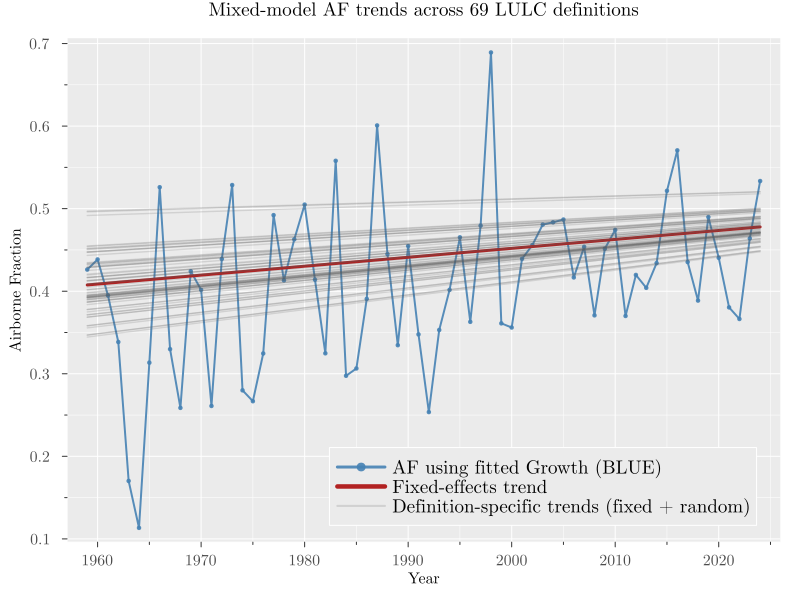

In [1]:
using Plots.PlotMeasures
years = sort(unique(long_df.Year))
t_vals = years .- minimum(years)

# Choose one observed AF definition to overlay for perspective.
overlay_def = first(group_df.definition)
overlay_df = long_df[long_df.definition .== overlay_def, [:Year, :AF]]

p_mm = plot(
    title = "Mixed-model AF trends across 69 LULC definitions",
    xlabel = "Year",
    ylabel = "Airborne Fraction",
    size = (800, 600),
    margin = 3mm,
    legend = :topleft,
)


# Overlay one observed AF series for context.
plot!(
    p_mm,
    overlay_df.Year,
    overlay_df.AF;
    color = :steelblue,
    linewidth = 2.0,
    linestyle = :solid,
    marker = :circle,
    markersize = 2.5,
    alpha = 0.9,
    label = "AF using fitted Growth ($(overlay_def))",
)

# Plot fixed-effects trend as a solid highlighted line.
yhat_fixed = summary_df.mu_alpha[1] .+ summary_df.mu_beta[1] .* t_vals
plot!(
    p_mm,
    years,
    yhat_fixed;
    color = :firebrick,
    linewidth = 3.0,
    linestyle = :solid,
    label = "Fixed-effects trend",
    legend = :bottomright
)

# Plot 69 definition-specific lines: fixed + random effects (translucent).
for (j, r) in enumerate(eachrow(group_df))
    alpha_j = r.alpha_j
    beta_j = r.beta_j
    yhat_j = alpha_j .+ beta_j .* t_vals
    plot!(
        p_mm,
        years,
        yhat_j;
        color = :gray35,
        alpha = 0.18,
        linewidth = 1.4,
        linestyle = :solid,
        label = (j == 1 ? "Definition-specific trends (fixed + random)" : nothing),
    )
end

p_mm

Save the mixed model plot.

In [1]:
savefig(p_mm, joinpath(@__DIR__, "..", "figures", "AF_mixed_model_definition_trends.png"))
savefig(p_mm, joinpath(@__DIR__, "..", "figures", "AF_mixed_model_definition_trends.pdf"))

"/Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/figures/AF_mixed_model_definition_trends.pdf"

## Subsample up to 2023

In [1]:
long_df_2023 = filter(row -> row.Year <= 2023, long_df)

### Mixed model without AR1 (Julia)

In [1]:
mmodel_2023_no_ar1_jl = fit_mixed_model(long_df_2023)
group_df_2023 = extract_group_coefficients(mmodel_2023_no_ar1_jl, long_df_2023)
summary_df_2023 = summarize_population_effects(mmodel_2023_no_ar1_jl, group_df_2023)
no_ar1_stats_2023 = extract_fixed_effect_stats(mmodel_2023_no_ar1_jl, long_df_2023)

DataFrame(
    model = ["No AR1 (Julia)"],
    alpha = [no_ar1_stats_2023.est_intercept],
    alpha_se = [no_ar1_stats_2023.se_intercept],
    alpha_pvalue = [no_ar1_stats_2023.p_intercept],
    beta = [no_ar1_stats_2023.est_slope],
    beta_se = [no_ar1_stats_2023.se_slope],
    beta_pvalue = [no_ar1_stats_2023.p_slope],
    r_squared_marginal = [no_ar1_stats_2023.r2_marginal],
    r_squared_conditional = [no_ar1_stats_2023.r2_conditional],
)

Plot the mixed model results for the subsample.


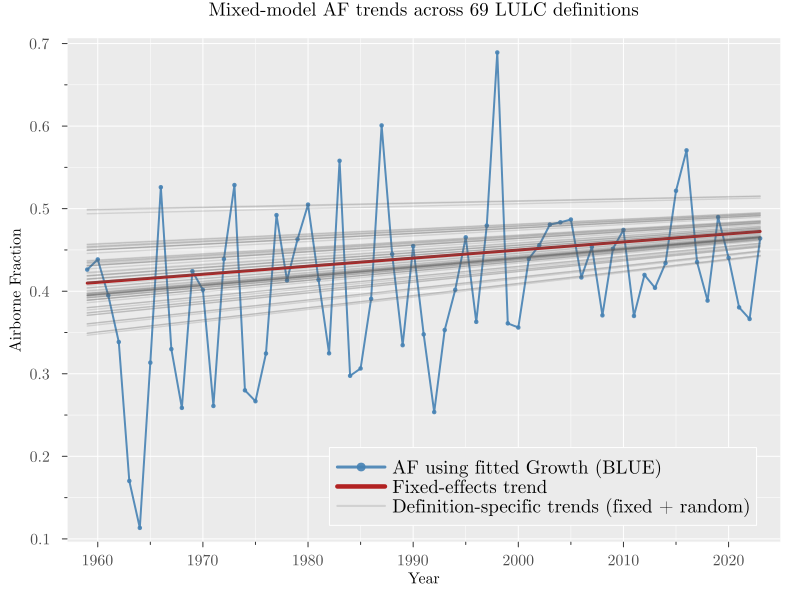

In [1]:
years_2023 = sort(unique(long_df_2023.Year))
t_vals = years_2023 .- minimum(years_2023)

# Choose one observed AF definition to overlay for perspective.
overlay_def = first(group_df_2023.definition)
overlay_df = long_df_2023[long_df_2023.definition .== overlay_def, [:Year, :AF]]

p_mm_2023 = plot(
    title = "Mixed-model AF trends across 69 LULC definitions",
    xlabel = "Year",
    ylabel = "Airborne Fraction",
    size = (800, 600),
    margin = 3mm,
    legend = :topleft,
)


# Overlay one observed AF series for context.
plot!(
    p_mm_2023,
    overlay_df.Year,
    overlay_df.AF;
    color = :steelblue,
    linewidth = 2.0,
    linestyle = :solid,
    marker = :circle,
    markersize = 2.5,
    alpha = 0.9,
    label = "AF using fitted Growth ($(overlay_def))",
)

# Plot fixed-effects trend as a solid highlighted line.
yhat_fixed = summary_df_2023.mu_alpha[1] .+ summary_df_2023.mu_beta[1] .* t_vals
plot!(
    p_mm_2023,
    years_2023,
    yhat_fixed;
    color = :firebrick,
    linewidth = 3.0,
    linestyle = :solid,
    label = "Fixed-effects trend",
    legend = :bottomright
)

# Plot 69 definition-specific lines: fixed + random effects (translucent).
for (j, r) in enumerate(eachrow(group_df_2023))
    alpha_j = r.alpha_j
    beta_j = r.beta_j
    yhat_j = alpha_j .+ beta_j .* t_vals
    plot!(
        p_mm_2023,
        years_2023,
        yhat_j;
        color = :gray35,
        alpha = 0.18,
        linewidth = 1.4,
        linestyle = :solid,
        label = (j == 1 ? "Definition-specific trends (fixed + random)" : nothing),
    )
end

p_mm_2023

In [1]:
savefig(p_mm_2023, joinpath(@__DIR__, "..", "figures", "AF_mixed_model_definition_trends_up_to_2023.png"))
savefig(p_mm_2023, joinpath(@__DIR__, "..", "figures", "AF_mixed_model_definition_trends_up_to_2023.pdf"))

"/Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/figures/AF_mixed_model_definition_trends_up_to_2023.pdf"

## Mixed model with AR1 component (R)

### Full sample and up to 2023

In [1]:
using RCall

@rput long_df long_df_2023

In [1]:
R"""
library(nlme)

if (!requireNamespace("performance", quietly = TRUE)) {
    install.packages("performance", repos = "https://cloud.r-project.org")
}

extract_ar1_stats <- function(model_ar1) {
    phi <- as.numeric(coef(model_ar1$modelStruct$corStruct, unconstrained = FALSE))

    se_phi <- NA_real_
    ap <- model_ar1$apVar
    if (is.matrix(ap)) {
        nms <- colnames(ap)
        idx <- which(nms %in% c("corStruct", "Phi", "phi"))
        if (length(idx) > 0) {
            se_all <- sqrt(diag(ap))
            se_phi <- as.numeric(se_all[idx[1]])
        }
    }

    p_phi <- NA_real_
    if (!is.na(se_phi) && is.finite(se_phi) && se_phi > 0) {
        z_phi <- phi / se_phi
        p_phi <- 2 * pnorm(-abs(z_phi))
    }

    data.frame(
        ar1_estimate = phi,
        ar1_se = se_phi,
        ar1_pvalue = p_phi
    )
}

fit_ar1_bundle <- function(df) {
    df$definition <- as.factor(df$definition)
    df$t <- df$Year - min(df$Year)

    ctrl <- lmeControl(
        opt = "optim",
        msMaxIter = 500,
        maxIter = 200,
        niterEM = 80,
        tolerance = 1e-6,
        msVerbose = FALSE,
        returnObject = TRUE
    )

    model_ar1 <- lme(
        AF ~ t,
        random = ~ t | definition,
        correlation = corAR1(form = ~ t | definition),
        data = df,
        method = "REML",
        control = ctrl
    )

    t_ar1 <- summary(model_ar1)$tTable
    r2_ar1 <- suppressWarnings(performance::r2_nakagawa(model_ar1))

    fixed_stats <- data.frame(
        alpha = unname(fixef(model_ar1)[1]),
        alpha_se = unname(t_ar1["(Intercept)", "Std.Error"]),
        alpha_pvalue = unname(t_ar1["(Intercept)", "p-value"]),
        beta = unname(fixef(model_ar1)[2]),
        beta_se = unname(t_ar1["t", "Std.Error"]),
        beta_pvalue = unname(t_ar1["t", "p-value"]),
        r_squared_marginal = as.numeric(r2_ar1$R2_marginal),
        r_squared_conditional = as.numeric(r2_ar1$R2_conditional)
    )

    list(
        model = model_ar1,
        fixed = fixed_stats,
        ar1 = extract_ar1_stats(model_ar1),
        resid = as.numeric(residuals(model_ar1, type = "normalized"))
    )
}

ar1_full <- fit_ar1_bundle(long_df)
ar1_2023 <- fit_ar1_bundle(long_df_2023)

ar1_fixed_full <- ar1_full$fixed
ar1_fixed_2023 <- ar1_2023$fixed
ar1_stats_full <- ar1_full$ar1
ar1_stats_2023 <- ar1_2023$ar1
resid_ar1 <- ar1_full$resid

print(summary(ar1_full$model))
print(ar1_stats_full)
print(summary(ar1_2023$model))
print(ar1_stats_2023)
"""

Linear mixed-effects model fit by REML
  Data: df 
       AIC       BIC   logLik
  -7916.79 -7871.827 3965.395

Random effects:
 Formula: ~t | definition
 Structure: General positive-definite, Log-Cholesky parametrization
            StdDev      Corr  
(Intercept) 0.035517758 (Intr)
t           0.000296211 -0.976
Residual    0.101516181       

Correlation Structure: AR(1)
 Formula: ~t | definition 
 Parameter estimate(s):
      Phi 
0.1777017 
Fixed effects:  AF ~ t 
                Value   Std.Error   DF  t-value p-value
(Intercept) 0.4085550 0.005545510 4484 73.67312       0
t           0.0010699 0.000100145 4484 10.68384       0
 Correlation: 
  (Intr)
t -0.78 

Standardized Within-Group Residuals:
        Min          Q1         Med          Q3         Max 
-3.09741880 -0.70278381 -0.02016192  0.55788290  3.54836048 

Number of Observations: 4554
Number of Groups: 69 
  ar1_estimate     ar1_se   ar1_pvalue
1    0.1777017 0.03101788 1.010191e-08
Linear mixed-effects model fit by RE

RObject{VecSxp}
  ar1_estimate    ar1_se  ar1_pvalue
1    0.1779503 0.0311155 1.07137e-08

In [1]:
@rget ar1_fixed_full ar1_fixed_2023 ar1_stats_full ar1_stats_2023 resid_ar1

ar1_fixed_full
ar1_stats_full
ar1_fixed_2023
ar1_stats_2023

## Results

### Fixed-effects summary (mixed models)

In [1]:
#| results: asis
mixed_results_table = DataFrame(
    Specification = [
        "Full sample (No AR1)",
        "Full sample (AR1)",
        "Up to 2023 (No AR1)",
        "Up to 2023 (AR1)",
    ],
    Intercept = [
        no_ar1_stats_full.est_intercept,
        ar1_fixed_full.alpha[1],
        no_ar1_stats_2023.est_intercept,
        ar1_fixed_2023.alpha[1],
    ],
    Trend = [
        no_ar1_stats_full.est_slope,
        ar1_fixed_full.beta[1],
        no_ar1_stats_2023.est_slope,
        ar1_fixed_2023.beta[1],
    ],
    InterceptSE = [
        no_ar1_stats_full.se_intercept,
        ar1_fixed_full.alpha_se[1],
        no_ar1_stats_2023.se_intercept,
        ar1_fixed_2023.alpha_se[1],
    ],
    InterceptPValue = [
        no_ar1_stats_full.p_intercept,
        ar1_fixed_full.alpha_pvalue[1],
        no_ar1_stats_2023.p_intercept,
        ar1_fixed_2023.alpha_pvalue[1],
    ],
    TrendSE = [
        no_ar1_stats_full.se_slope,
        ar1_fixed_full.beta_se[1],
        no_ar1_stats_2023.se_slope,
        ar1_fixed_2023.beta_se[1],
    ],
    TrendPValue = [
        no_ar1_stats_full.p_slope,
        ar1_fixed_full.beta_pvalue[1],
        no_ar1_stats_2023.p_slope,
        ar1_fixed_2023.beta_pvalue[1],
    ],
    RSquaredMarginal = [
        no_ar1_stats_full.r2_marginal,
        ar1_fixed_full.r_squared_marginal[1],
        no_ar1_stats_2023.r2_marginal,
        ar1_fixed_2023.r_squared_marginal[1],
    ],
    RSquaredConditional = [
        no_ar1_stats_full.r2_conditional,
        ar1_fixed_full.r_squared_conditional[1],
        no_ar1_stats_2023.r2_conditional,
        ar1_fixed_2023.r_squared_conditional[1],
    ],
    AR1Estimate = [
        NaN,
        ar1_stats_full.ar1_estimate[1],
        NaN,
        ar1_stats_2023.ar1_estimate[1],
    ],
    AR1SE = [
        NaN,
        ar1_stats_full.ar1_se[1],
        NaN,
        ar1_stats_2023.ar1_se[1],
    ],
    AR1PValue = [
        NaN,
        ar1_stats_full.ar1_pvalue[1],
        NaN,
        ar1_stats_2023.ar1_pvalue[1],
    ],
)

function dataframe_to_markdown_table_generic(df::DataFrame; digits::Int=6)
    fmt(x) = x isa Number ? string(round(x; digits = digits)) : string(x)

    headers = names(df)
    header_row = "| " * join(headers, " | ") * " |"
    sep_row = "|" * join(fill("---", length(headers)), "|") * "|"

    rows = String[]
    for r in eachrow(df)
        vals = [fmt(r[h]) for h in headers]
        push!(rows, "| " * join(vals, " | ") * " |")
    end

    return join([header_row, sep_row, rows...], "\n") * "\n"
end

mixed_table_md = dataframe_to_markdown_table_generic(mixed_results_table)

println(mixed_table_md)

mixed_out_path = joinpath(@__DIR__, "..", "results", "af_growth_mixed_model_fixed_effects_summary_table.md")
open(mixed_out_path, "w") do io
    write(io, mixed_table_md)
end

println("Saved mixed-model summary table to: $(mixed_out_path)")

| Specification | Intercept | Trend | InterceptSE | InterceptPValue | TrendSE | TrendPValue | RSquaredMarginal | RSquaredConditional | AR1Estimate | AR1SE | AR1PValue |
|---|---|---|---|---|---|---|---|---|---|---|---|
| Full sample (No AR1) | 0.407572 | 0.001082 | 0.005324 | 0.0 | 8.6e-5 | 0.0 | 0.037595 | 0.094175 | NaN | NaN | NaN |
| Full sample (AR1) | 0.408555 | 0.00107 | 0.005546 | 0.0 | 0.0001 | 0.0 | 0.036325 | 0.099139 | 0.177702 | 0.031018 | 0.0 |
| Up to 2023 (No AR1) | 0.409783 | 0.000978 | 0.005345 | 0.0 | 8.8e-5 | 0.0 | 0.029853 | 0.086631 | NaN | NaN | NaN |
| Up to 2023 (AR1) | 0.411223 | 0.000944 | 0.005564 | 0.0 | 0.000102 | 0.0 | 0.027524 | 0.090792 | 0.17795 | 0.031115 | 0.0 |

Saved mixed-model summary table to: /Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/scripts/../results/af_growth_mixed_model_fixed_effects_summary_table.md